<a href="https://colab.research.google.com/github/utkarsh4tech/customer_segmentation/blob/main/CustomerSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation on Online Retail Dataset (UCI)

# Loading important Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Information about Dataset

This Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.

### Additional Information

InvoiceNo: Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation.

StockCode: Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product.

Description: Product (item) name. Nominal.

Quantity: The quantities of each product (item) per transaction. Numeric.

InvoiceDate: Invice date and time. Numeric. The day and time when a transaction was generated.

UnitPrice: Unit price. Numeric. Product price per unit in sterling (Â£).

CustomerID: Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer.

Country: Country name. Nominal. The name of the country where a customer resides.



# Loading and Reviewing the data

In [ ]:
import pandas as pd

# SOURCE https://archive.ics.uci.edu/dataset/502/online+retail+ii

filepath = "/content/online_retail_II.xlsx"
f = pd.ExcelFile(filepath)
list_of_dfs = []

for sheet in f.sheet_names:

    df = f.parse(sheet)
    list_of_dfs.append(df)

df = pd.concat(list_of_dfs, ignore_index=True)

In [ ]:
df.sample(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
790900,560225,20619,TROPICAL PASSPORT COVER,6,2011-07-15 16:27:00,1.63,NaN,United Kingdom
412237,528766,85099F,JUMBO BAG STRAWBERRY,10,2010-10-24 16:13:00,1.95,13564.0,United Kingdom
592927,541830,21154,RED RETROSPOT OVEN GLOVE,2,2011-01-21 17:09:00,2.46,NaN,United Kingdom
869829,567043,23168,CLASSIC CAFE SUGAR DISPENSER,3,2011-09-16 11:27:00,1.25,13268.0,United Kingdom
241137,512725,22498,WOODEN REGATTA BUNTING,1,2010-06-17 13:09:00,5.95,14508.0,United Kingdom
668887,548701,84692,BOX OF 24 COCKTAIL PARASOLS,1,2011-04-03 11:36:00,0.42,17629.0,United Kingdom
856914,566016,22725,ALARM CLOCK BAKELIKE CHOCOLATE,4,2011-09-08 12:20:00,3.75,15144.0,United Kingdom
570785,540255,47563A,RETRO LONGBOARD IRONING BOARD COVER,1,2011-01-05 16:50:00,3.36,NaN,United Kingdom
591831,541792,22356,CHARLOTTE BAG PINK POLKADOT,10,2011-01-21 13:09:00,0.85,17094.0,United Kingdom
959026,573931,22902,TOTE BAG I LOVE LONDON,12,2011-11-02 10:16:00,2.10,16884.0,United Kingdom


In [ ]:
df.shape

(1067371, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,1067371.0,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.0,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445


In [ ]:
df.describe(include='O').T

,count,unique,top,freq
Invoice,1067371,53628,537434,1350
StockCode,1067371,5305,85123A,5829
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918
Country,1067371,43,United Kingdom,981330


# Data Sanity Check

In [ ]:
df[df["Customer ID"].isna()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [ ]:
df["Invoice"] = df["Invoice"].astype("str")
df[df["Invoice"].str.match("^\\d{6}$") == False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [ ]:
df["Invoice"].str.replace("[0-9]", "", regex=True).unique()

array(['', 'C', 'A'], dtype=object)

In [ ]:
df[df["Invoice"].str.startswith("A")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [ ]:
df["StockCode"] = df["StockCode"].astype("str")
df[(df["StockCode"].str.match("^\\d{5}$") == False) & (df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == False)]["StockCode"].unique()

array(['POST', 'D', 'DCGS0058', 'DCGS0068', 'DOT', 'M', 'DCGS0004',
       'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003', 'TEST001',
       'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044', 'TEST002',
       'gift_0001_10', 'gift_0001_50', 'DCGS0066N', 'gift_0001_30',
       'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', '47503J ', 'C3', 'SP1002', 'AMAZONFEE',
       'DCGS0055', 'DCGS0074', 'DCGS0057', 'DCGS0073', 'DCGS0071',
       'DCGS0066P', 'DCGS0067', 'CRUK'], dtype=object)

In [ ]:
df[df["StockCode"].str.contains("^DOT")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,2009-12-01 14:45:00,59.35,NaN,United Kingdom
2619,489603,DOT,DOTCOM POSTAGE,1,2009-12-01 14:46:00,42.39,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
1062295,581219,DOT,DOTCOM POSTAGE,1,2011-12-08 09:28:00,1008.96,NaN,United Kingdom
1062715,581238,DOT,DOTCOM POSTAGE,1,2011-12-08 10:53:00,1683.75,NaN,United Kingdom
1064829,581439,DOT,DOTCOM POSTAGE,1,2011-12-08 16:30:00,938.59,NaN,United Kingdom
1066369,581492,DOT,DOTCOM POSTAGE,1,2011-12-09 10:03:00,933.17,NaN,United Kingdom


In [ ]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


# Data Cleaning

In [ ]:
df_clean = df.copy()

In [ ]:
df_clean["Invoice"] = df_clean["Invoice"].astype("str")

df_clean = df_clean[(
    df_clean["Invoice"].str.match("^\\d{6}$") == True
)]

df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [ ]:
df_clean["StockCode"] = df_clean["StockCode"].astype("str")

cleaned_df = df_clean[(
    (df_clean["StockCode"].str.match("^\\d{5}$") == True)
    | (df_clean["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == True)
    | (df_clean["StockCode"].str.match("^PADS$") == True)
)]

df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [ ]:
df_clean.dropna(subset=["Customer ID"], inplace=True)

In [ ]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,805620.0,13.307665,1.0,2.0,5.0,12.0,80995.0,144.306739
InvoiceDate,805620,2011-01-02 10:26:35.704326144,2009-12-01 07:45:00,2010-07-07 12:08:00,2010-12-03 15:10:00,2011-07-28 13:28:00,2011-12-09 12:50:00,NaN
Price,805620.0,3.206279,0.0,1.25,1.95,3.75,10953.5,29.197901
Customer ID,805620.0,15331.85625,12346.0,13982.0,15271.0,16805.0,18287.0,1696.768395


In [ ]:
df_clean[df_clean["Price"] == 0]

# 71 rows have 0 price??

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
...,...,...,...,...,...,...,...,...
1004540,577129,22464,HANGING METAL HEART LANTERN,4,2011-11-17 19:52:00,0.0,15602.0,United Kingdom
1005014,577168,M,Manual,1,2011-11-18 10:42:00,0.0,12603.0,Germany
1006110,577314,23407,SET OF 2 TRAYS HOME SWEET HOME,2,2011-11-18 13:23:00,0.0,12444.0,Norway
1011446,577696,M,Manual,1,2011-11-21 11:57:00,0.0,16406.0,United Kingdom


In [ ]:
df_clean = df_clean[df_clean["Price"] > 0.0]
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,805549.0,13.290522,1.0,2.0,5.0,12.0,80995.0,143.634088
InvoiceDate,805549,2011-01-02 10:24:44.106814464,2009-12-01 07:45:00,2010-07-07 12:08:00,2010-12-03 15:10:00,2011-07-28 13:05:00,2011-12-09 12:50:00,NaN
Price,805549.0,3.206561,0.001,1.25,1.95,3.75,10953.5,29.199173
Customer ID,805549.0,15331.95497,12346.0,13982.0,15271.0,16805.0,18287.0,1696.737039


In [ ]:
df_clean = df_clean[df_clean["Quantity"] > 0.0]
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,805549.0,13.290522,1.0,2.0,5.0,12.0,80995.0,143.634088
InvoiceDate,805549,2011-01-02 10:24:44.106814464,2009-12-01 07:45:00,2010-07-07 12:08:00,2010-12-03 15:10:00,2011-07-28 13:05:00,2011-12-09 12:50:00,NaN
Price,805549.0,3.206561,0.001,1.25,1.95,3.75,10953.5,29.199173
Customer ID,805549.0,15331.95497,12346.0,13982.0,15271.0,16805.0,18287.0,1696.737039


In [ ]:
retained_percent = len(df_clean)/len(df)*100
print(f'''
    {retained_percent:.2f}% rows in dataset were retained and {100-retained_percent:.2f}% were dropped
''')


    75.47% rows in dataset were retained and 24.53% were dropped



# Feature Engineering

In [ ]:
df_clean["SalesLineTotal"] = df_clean["Quantity"] * df_clean["Price"]

df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85


In [ ]:
aggregated_df = df_clean.groupby(by="Customer ID", as_index=False).agg(
        MonetaryValue=("SalesLineTotal", "sum"),
        Frequency=("Invoice", "nunique"),
        LastInvoiceDate=("InvoiceDate", "max")
    )

aggregated_df.sample(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
5055,17456.0,1225.42,2,2010-12-09 15:23:00
535,12883.0,703.47,4,2011-11-15 09:32:00
3273,15651.0,1259.06,5,2011-11-03 08:41:00
3296,15674.0,6948.23,13,2011-09-27 15:17:00
2020,14389.0,1898.01,5,2011-10-05 15:17:00


In [ ]:
print(f"After Aggregation size of dataset:{aggregated_df.shape[0]}")

After Aggregation size of dataset:5878


In [ ]:
aggregated_df["Recency"] = (aggregated_df["LastInvoiceDate"].max() - aggregated_df["LastInvoiceDate"]).dt.days

aggregated_df.sample(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
4865,17262.0,2757.62,11,2011-10-18 12:56:00,51
5587,17996.0,482.33,3,2010-11-25 11:00:00,379
865,13216.0,333.74,1,2011-03-17 12:18:00,267
3125,15503.0,267.15,2,2010-12-12 10:57:00,362
2193,14562.0,6729.40,26,2011-12-06 11:05:00,3


# Exploratory Data Analysis

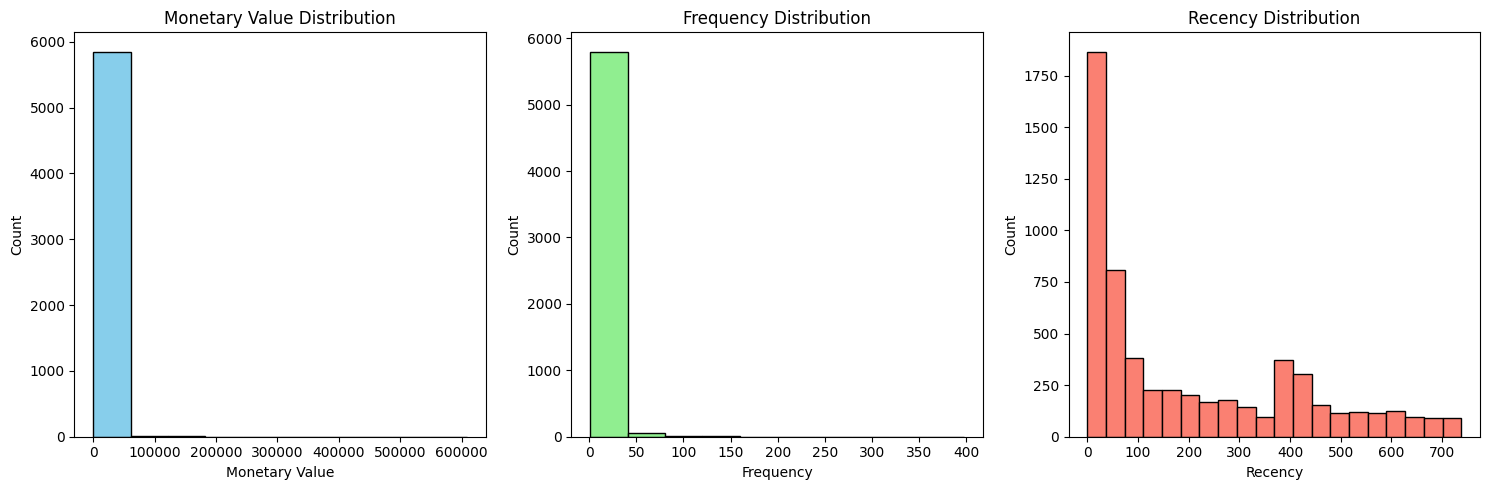

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(aggregated_df['MonetaryValue'], bins=10, color='skyblue', edgecolor='black')
plt.title('Monetary Value Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
plt.hist(aggregated_df['Frequency'], bins=10, color='lightgreen', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
plt.hist(aggregated_df['Recency'], bins=20, color='salmon', edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Recency')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

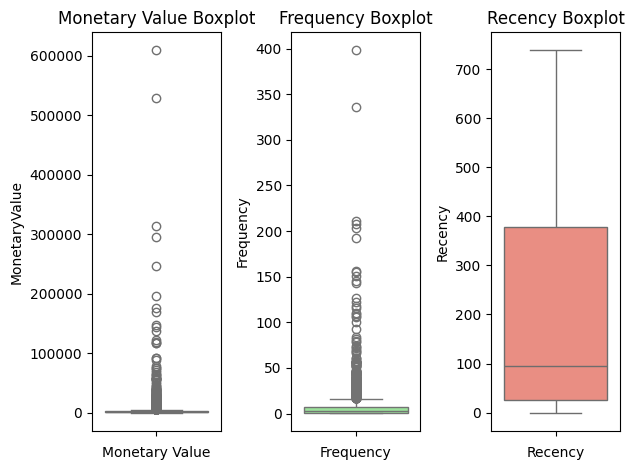

In [ ]:

plt.subplot(1, 3, 1)
sns.boxplot(data=aggregated_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=aggregated_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=aggregated_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

In [ ]:
def return_outlier_df(col_name):
  df_Q1 = aggregated_df[col_name].quantile(0.25)
  df_Q3 = aggregated_df[col_name].quantile(0.75)
  df_IQR = df_Q3 - df_Q1

  outliers_df = aggregated_df[(aggregated_df[col_name] > (df_Q3 + 1.5 * df_IQR)) | (aggregated_df[col_name] < (df_Q1 - 1.5 * df_IQR))].copy()

  return outliers_df



In [ ]:
monetary_outliers_df = return_outlier_df("MonetaryValue")
print(f"{monetary_outliers_df.shape[0]} people are in outlier dataset wrt to monetory value")
print("*"*50)
monetary_outliers_df.describe().T

628 people are in outlier dataset wrt to monetory value
**************************************************


,count,mean,min,25%,50%,75%,max,std
Customer ID,628.0,15044.598726,12346.0,13493.25,14901.0,16556.5,18260.0,1760.756606
MonetaryValue,628.0,18406.139217,5246.63,6640.1925,9197.865,14557.9,608821.65,41936.566106
Frequency,628.0,26.063694,1.0,12.0,18.5,29.0,398.0,31.902549
LastInvoiceDate,628,2011-10-17 20:09:46.624203776,2010-01-17 11:33:00,2011-10-23 01:02:00,2011-11-23 12:05:30,2011-12-05 09:29:15,2011-12-09 12:49:00,NaN
Recency,628.0,52.210191,0.0,4.0,16.0,47.25,691.0,105.219663


In [ ]:
freq_outliers_df = return_outlier_df("Frequency")
print(f"{freq_outliers_df.shape[0]} people are in outlier dataset wrt to frequency they buy")
print("*"*50)
freq_outliers_df.describe().T

427 people are in outlier dataset wrt to frequency they buy
**************************************************


,count,mean,min,25%,50%,75%,max,std
Customer ID,427.0,15366.875878,12415.0,13836.5,15301.0,16949.5,18283.0,1786.732786
MonetaryValue,427.0,21393.214016,1820.44,6494.745,9784.67,17147.67,608821.65,49740.09036
Frequency,427.0,35.119438,17.0,20.0,25.0,35.0,398.0,35.705134
LastInvoiceDate,427,2011-11-08 15:18:35.831381504,2010-05-12 16:51:00,2011-11-14 12:29:30,2011-11-30 10:54:00,2011-12-06 12:40:00,2011-12-09 12:49:00,NaN
Recency,427.0,30.409836,0.0,3.0,9.0,24.5,575.0,68.320243


In [ ]:
non_outliers_df = aggregated_df[(~aggregated_df.index.isin(monetary_outliers_df.index)) & (~aggregated_df.index.isin(freq_outliers_df.index))]

non_outliers_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Customer ID,5184.0,15340.802276,12348.0,13862.75,15351.5,16810.25,18287.0,1704.336843
MonetaryValue,5184.0,1141.781723,2.95,312.6425,722.65,1593.4925,5232.23,1138.751808
Frequency,5184.0,3.696952,1.0,1.0,3.0,5.0,16.0,3.203405
LastInvoiceDate,5184,2011-05-02 18:25:45.196759296,2009-12-01 09:55:00,2010-11-10 13:32:45,2011-07-26 01:04:00,2011-11-06 12:32:00,2011-12-09 12:50:00,NaN
Recency,5184.0,220.240355,0.0,33.0,136.0,393.0,738.0,211.916115


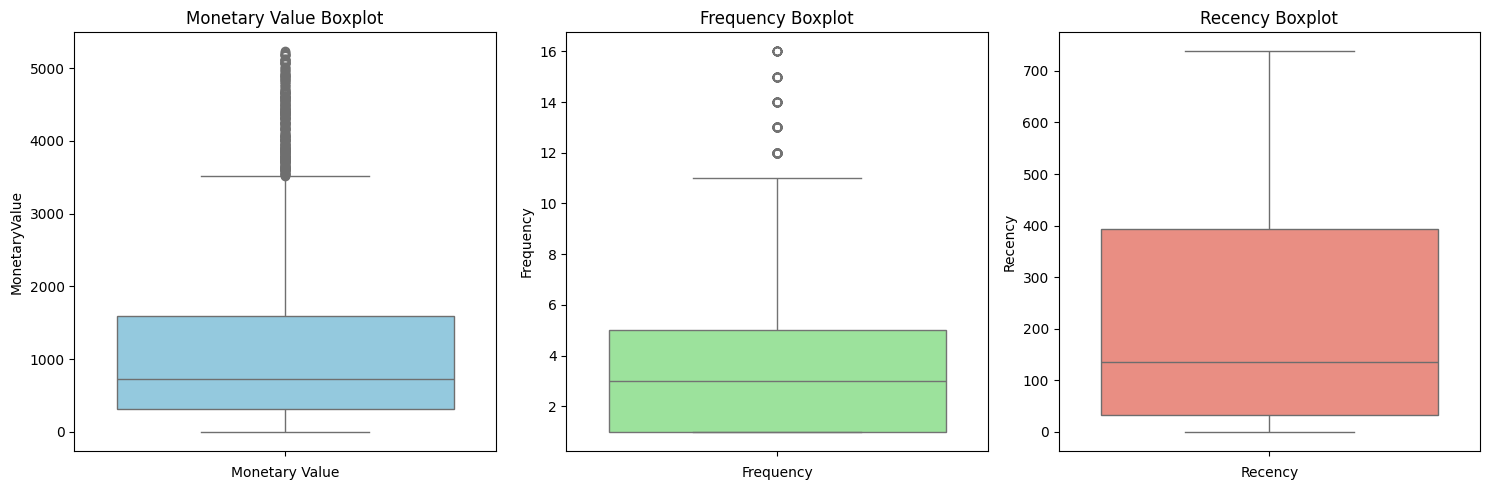

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=non_outliers_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=non_outliers_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=non_outliers_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

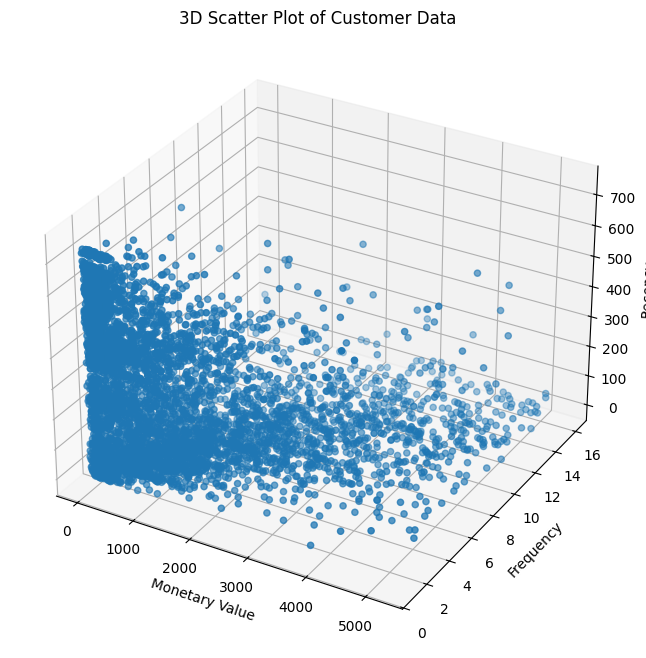

In [ ]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(non_outliers_df["MonetaryValue"], non_outliers_df["Frequency"], non_outliers_df["Recency"])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data')

plt.show()

In [ ]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(non_outliers_df[["MonetaryValue", "Frequency", "Recency"]])

In [ ]:
scaled_data_df = pd.DataFrame(scaled_data, index=non_outliers_df.index, columns=("MonetaryValue", "Frequency", "Recency"))

scaled_data_df

,MonetaryValue,Frequency,Recency
2,0.770759,0.406809,-0.690153
3,2.886692,0.094611,-0.954434
4,-0.709074,-0.841983,0.418884
5,-0.738469,-0.841983,0.725638
6,1.500084,1.967799,-0.874205
...,...,...,...
5872,-0.846387,-0.529785,-1.006346
5874,-0.597292,-0.841983,0.994639
5875,-0.627749,-0.841983,2.075359
5876,0.135818,-0.529785,1.207007


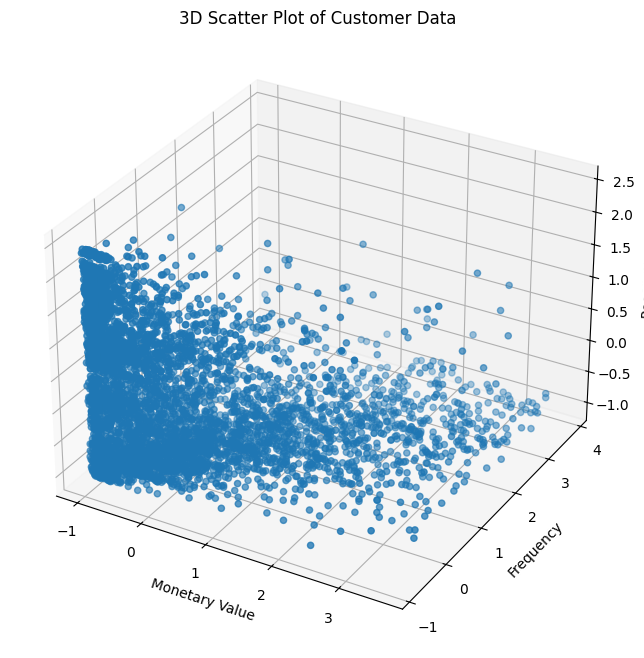

In [ ]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(scaled_data_df["MonetaryValue"], scaled_data_df["Frequency"], scaled_data_df["Recency"])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data')

plt.show()

# Customer Segmentation / KMeans application

In [ ]:
max_k = 15

inertia = []
silhoutte_scores = []
k_values = range(2, max_k + 1)

for k in k_values:

    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)

    cluster_labels = kmeans.fit_predict(scaled_data_df)

    sil_score = silhouette_score(scaled_data_df, cluster_labels)

    silhoutte_scores.append(sil_score)

    inertia.append(kmeans.inertia_)



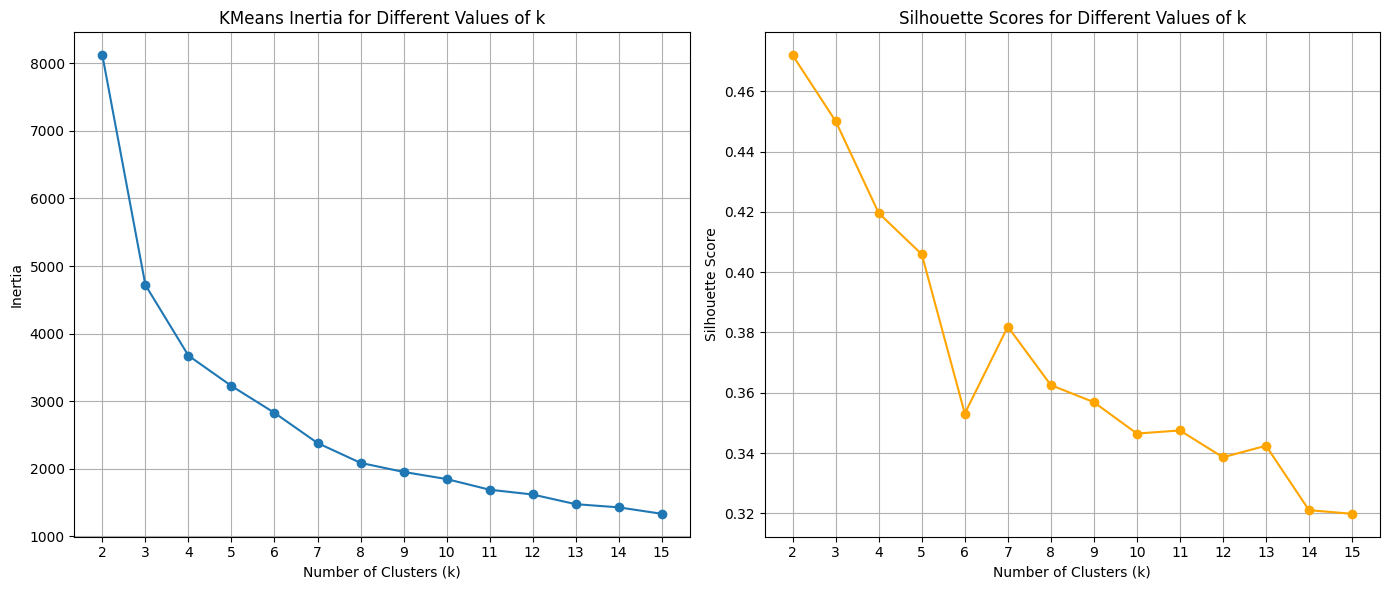

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o')
plt.title('KMeans Inertia for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhoutte_scores, marker='o', color='orange')
plt.title('Silhouette Scores for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

# Inference

From the two diagrams above we can see that optimal number of customers can be 4 or 5 (using elbow method). Since the Silhouette score for k=4 is higher, we can finalise 4 for our segmentation

In [ ]:
optimal_k = 4 # from above

kmeans = KMeans(n_clusters=optimal_k, random_state=42, max_iter=1000)
cluster_labels = kmeans.fit_predict(scaled_data_df)
cluster_labels

array([3, 1, 2, ..., 2, 2, 1], dtype=int32)

In [ ]:
non_outliers_df["Cluster"] = cluster_labels

non_outliers_df

/tmp/ipykernel_8337/3577770544.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers_df["Cluster"] = cluster_labels


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
2,12348.0,2019.40,5,2011-09-25 13:13:00,74,3
3,12349.0,4428.69,4,2011-11-21 09:51:00,18,1
4,12350.0,334.40,1,2011-02-02 16:01:00,309,2
5,12351.0,300.93,1,2010-11-29 15:23:00,374,2
6,12352.0,2849.84,10,2011-11-03 14:37:00,35,1
...,...,...,...,...,...,...
5872,18282.0,178.05,2,2011-12-02 11:43:00,7,0
5874,18284.0,461.68,1,2010-10-04 11:33:00,431,2
5875,18285.0,427.00,1,2010-02-17 10:24:00,660,2
5876,18286.0,1296.43,2,2010-08-20 11:57:00,476,2


In [ ]:
cluster_colors = {
        0: 'red',
        1: 'green',
        2: 'blue',
        3: 'orange'
    }

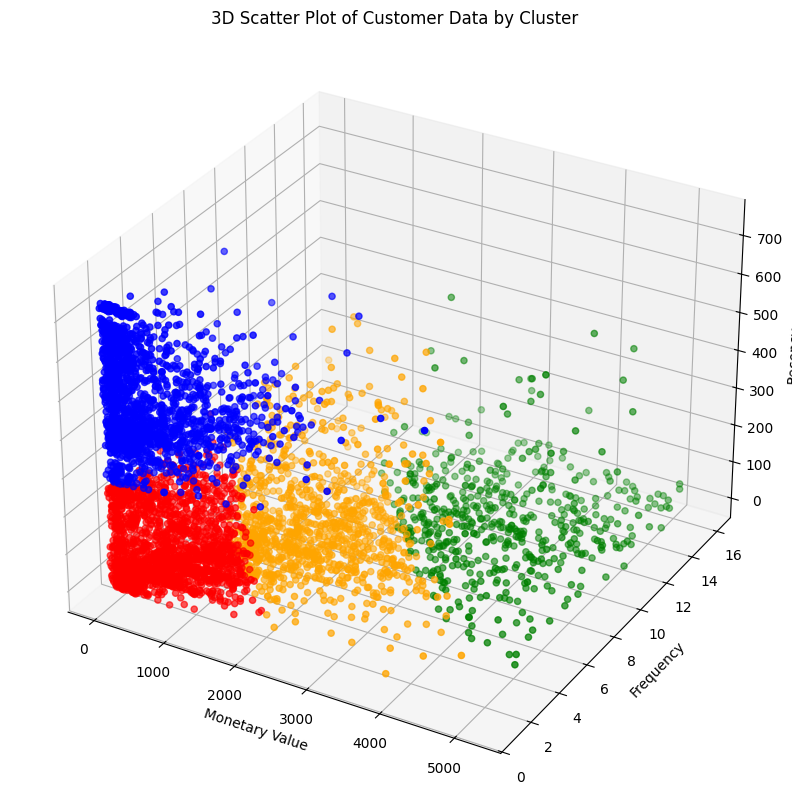

In [ ]:
colors = non_outliers_df['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(non_outliers_df['MonetaryValue'],
                     non_outliers_df['Frequency'],
                     non_outliers_df['Recency'],
                     c=colors,  # Use mapped solid colors
                     marker='o')

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data by Cluster')

plt.show()

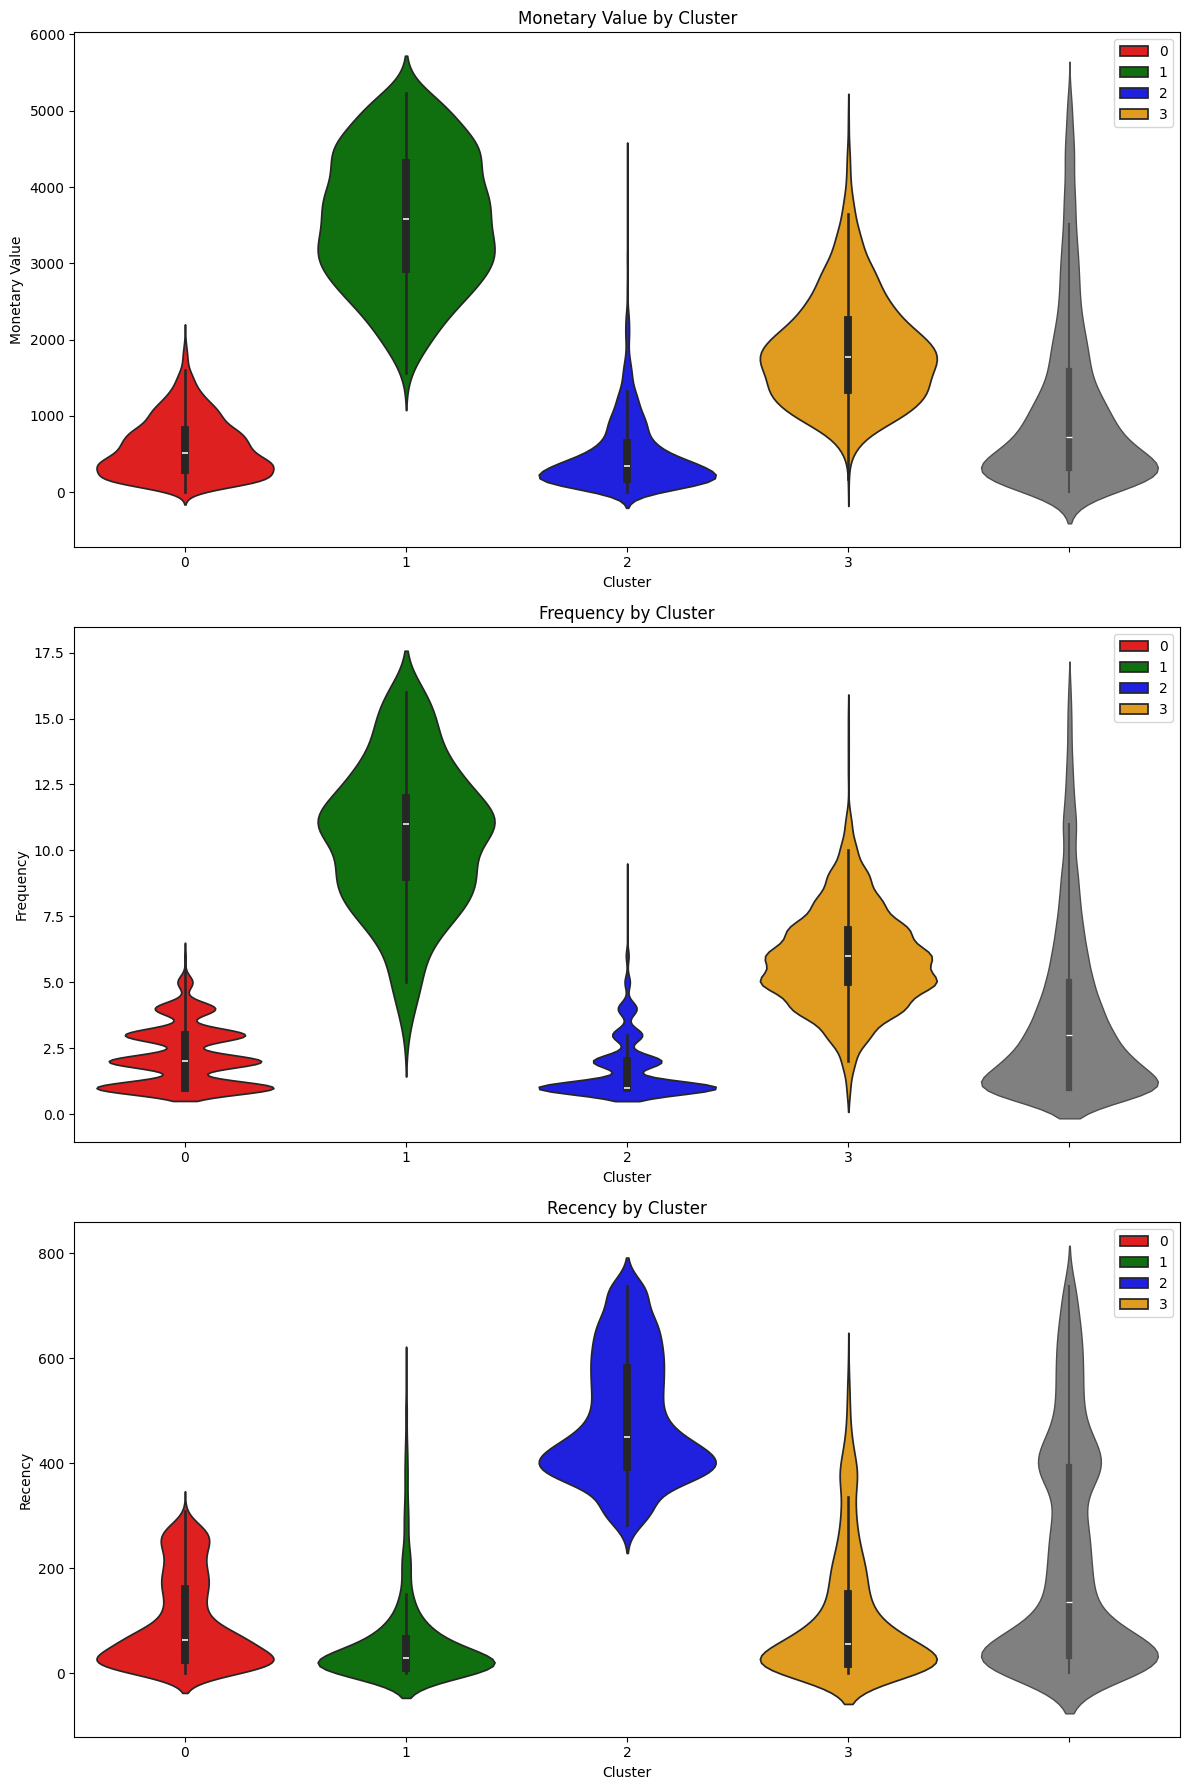

In [ ]:
plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['MonetaryValue'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Frequency'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['Frequency'], color='gray', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')


plt.subplot(3, 1, 3)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Recency'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['Recency'], color='gray', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()


In [ ]:
overlap_indices = monetary_outliers_df.index.intersection(freq_outliers_df.index)

monetary_only_outliers = monetary_outliers_df.drop(overlap_indices)
frequency_only_outliers = freq_outliers_df.drop(overlap_indices)
monetary_and_frequency_outliers = monetary_outliers_df.loc[overlap_indices]

monetary_only_outliers["Cluster"] = -1
frequency_only_outliers["Cluster"] = -2
monetary_and_frequency_outliers["Cluster"] = -3

outlier_clusters_df = pd.concat([monetary_only_outliers, frequency_only_outliers, monetary_and_frequency_outliers])

outlier_clusters_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.0,77556.46,12,2011-01-18 10:01:00,325,-1
1,12347.0,5633.32,8,2011-12-07 15:52:00,1,-1
10,12356.0,6373.68,6,2011-11-17 08:40:00,22,-1
11,12357.0,18287.66,3,2011-11-06 16:07:00,32,-1
13,12359.0,8935.94,10,2011-10-13 12:47:00,57,-1
...,...,...,...,...,...,...
5816,18226.0,11878.88,26,2011-10-26 13:36:00,43,-3
5819,18229.0,10803.71,28,2011-11-28 09:48:00,11,-3
5821,18231.0,6880.97,28,2011-05-31 14:18:00,191,-3
5835,18245.0,6324.98,20,2011-12-02 14:48:00,6,-3


In [ ]:
cluster_colors = {
    0: 'red',
    1: 'green',
    2: 'blue',
    3: 'orange',
    -1: 'purple',
    -2: 'brown',
    -3: 'pink'
}

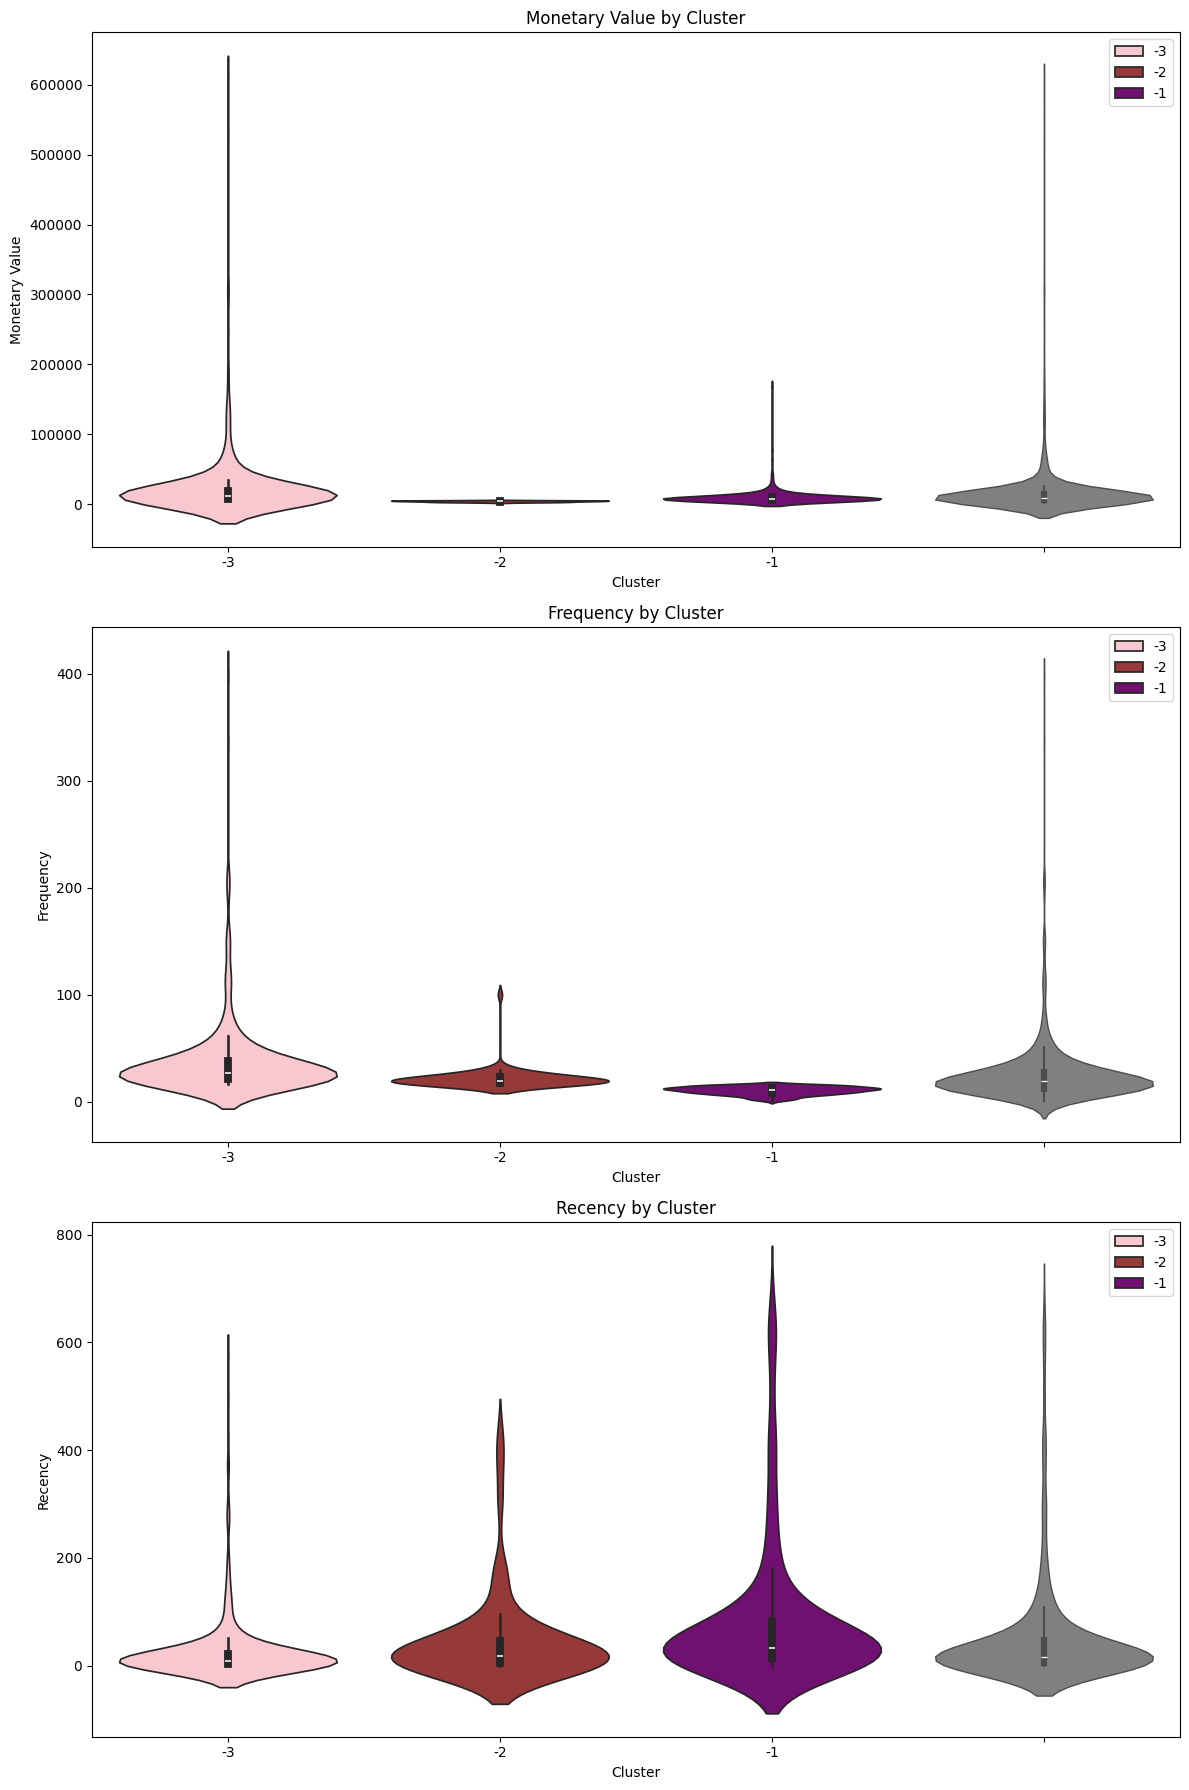

In [ ]:
plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['MonetaryValue'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Frequency'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['Frequency'], color='gray', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')

plt.subplot(3, 1, 3)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Recency'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['Recency'], color='gray', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

In [ ]:
cluster_labels = {
    0: "RETAIN",
    1: "RE-ENGAGE",
    2: "NURTURE",
    3: "REWARD",
    -1: "PAMPER",
    -2: "UPSELL",
    -3: "DELIGHT"
}

In [ ]:
full_clustering_df = pd.concat([non_outliers_df, outlier_clusters_df])

full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
2,12348.0,2019.40,5,2011-09-25 13:13:00,74,3
3,12349.0,4428.69,4,2011-11-21 09:51:00,18,1
4,12350.0,334.40,1,2011-02-02 16:01:00,309,2
5,12351.0,300.93,1,2010-11-29 15:23:00,374,2
6,12352.0,2849.84,10,2011-11-03 14:37:00,35,1
...,...,...,...,...,...,...
5816,18226.0,11878.88,26,2011-10-26 13:36:00,43,-3
5819,18229.0,10803.71,28,2011-11-28 09:48:00,11,-3
5821,18231.0,6880.97,28,2011-05-31 14:18:00,191,-3
5835,18245.0,6324.98,20,2011-12-02 14:48:00,6,-3


In [ ]:
full_clustering_df["ClusterLabel"] = full_clustering_df["Cluster"].map(cluster_labels)

full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster,ClusterLabel
2,12348.0,2019.40,5,2011-09-25 13:13:00,74,3,REWARD
3,12349.0,4428.69,4,2011-11-21 09:51:00,18,1,RE-ENGAGE
4,12350.0,334.40,1,2011-02-02 16:01:00,309,2,NURTURE
5,12351.0,300.93,1,2010-11-29 15:23:00,374,2,NURTURE
6,12352.0,2849.84,10,2011-11-03 14:37:00,35,1,RE-ENGAGE
...,...,...,...,...,...,...,...
5816,18226.0,11878.88,26,2011-10-26 13:36:00,43,-3,DELIGHT
5819,18229.0,10803.71,28,2011-11-28 09:48:00,11,-3,DELIGHT
5821,18231.0,6880.97,28,2011-05-31 14:18:00,191,-3,DELIGHT
5835,18245.0,6324.98,20,2011-12-02 14:48:00,6,-3,DELIGHT


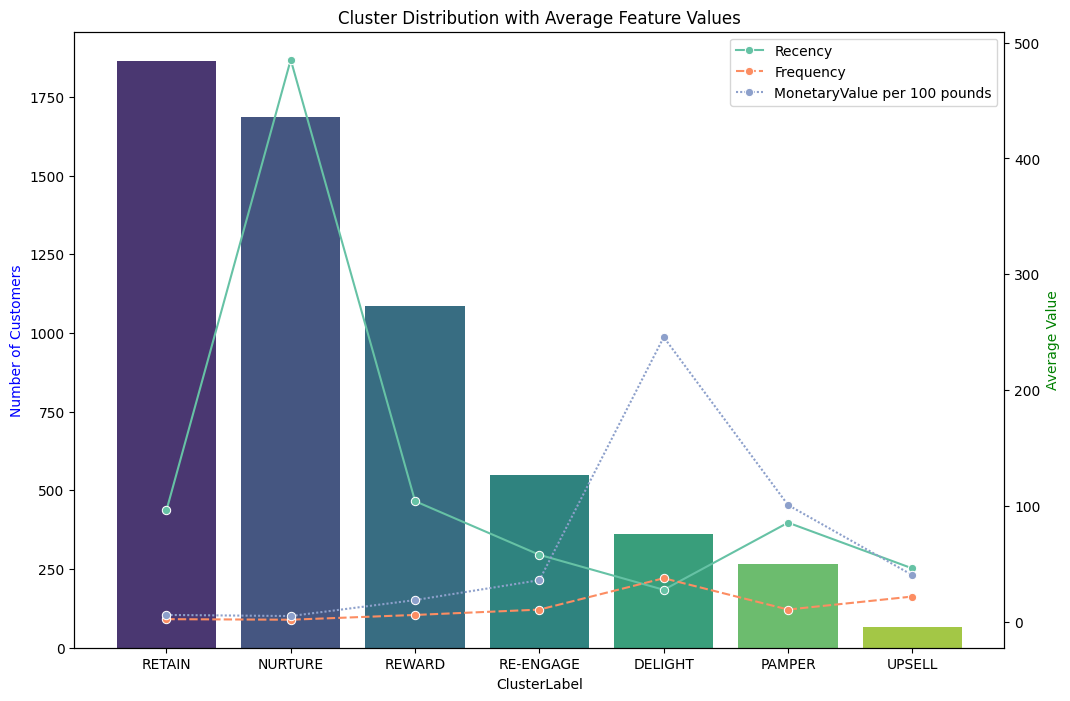

In [ ]:
cluster_counts = full_clustering_df['ClusterLabel'].value_counts()
full_clustering_df["MonetaryValue per 100 pounds"] = full_clustering_df["MonetaryValue"] / 100.00
feature_means = full_clustering_df.groupby('ClusterLabel')[['Recency', 'Frequency', 'MonetaryValue per 100 pounds']].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='viridis', hue=cluster_counts.index)
ax1.set_ylabel('Number of Customers', color='b')
ax1.set_title('Cluster Distribution with Average Feature Values')

ax2 = ax1.twinx()

sns.lineplot(data=feature_means, ax=ax2, palette='Set2', marker='o')
ax2.set_ylabel('Average Value', color='g')

plt.show()

# Summary